Narzędzia i organizacja zajęć
===============================

Wykłady w postaci HTML będą pojawiać się na serwisie **Moodle** https://lms.amu.edu.pl/sci/course/view.php?id=333

W tym samym miejscu obecne będą materiały na laboratoria. Na samym dole materiałów na laboratoria publikowany będzie plik notatnika **Jupyter**, który można otworzyć w serwisie https://jupyter.wmi.amu.edu.pl by móc skorzystać z interaktywnych opcji uruchamiania kodów.

W ramach uruchamiania programów oraz debuggowania pomocne może być także bardziej złożone **IDE** (ang. Integrated Development Environment) o nazwie **PyCharm**, opisane poniżej.

W ramach wykładu na serwisie **Moodle** znajdziecie Państwo pytania testowe na które macie **2** tygodnie na odpowiedź. Tam też pod nazwą **Zadania** znajdować się będa zadania do wykonania na zajęciach laboratoryjnych (także dostępne przez **2** tygodnie do czasu zajęć). Korzystają one z pluginu **CodeRunner** systemu **Moodle**.

Edytor
--------

Implementując programy w języku Python, rekomendowanym (i aktualnie jednym z najpopularniejszych) rodzin IDE jest zespół oprogramowania dostarczany przez firmę **JetBrains**. Oprogramowanie to jest dostępne za darmo w wersji Community (link poniżej). Jako studenci możecie Państwo prosić o darmowy dostęp do wersji Ultimate - https://www.jetbrains.com/community/education/#students):

> https://www.jetbrains.com/pycharm

Otwórz program PyCharm. Powinieneś zobaczyć następujący ekran:

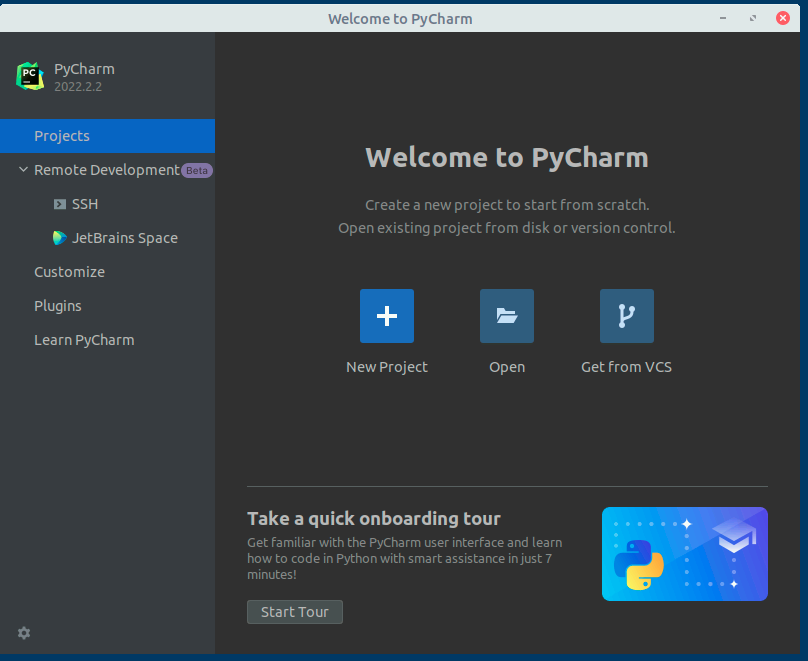

Utwórz **New Project -> Pure Python**.

W pierwszej lini przy location możesz zmienić nazwę projektu na własną i wybrać **create**.

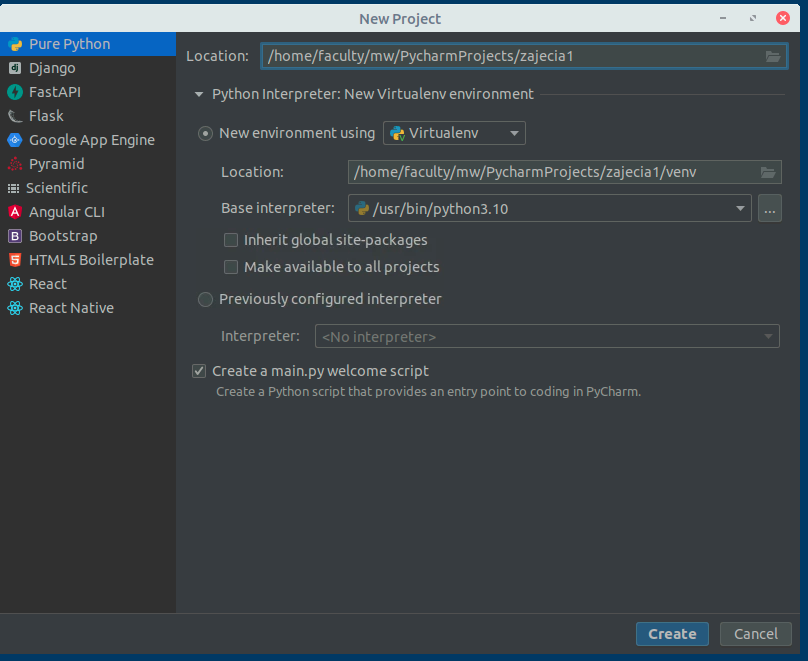

Powinieneś zobaczyć ekran edytora. Otwórz plik **main.py** wybierając z go z lewej strony w menu projektu. Tak wygląda menu:

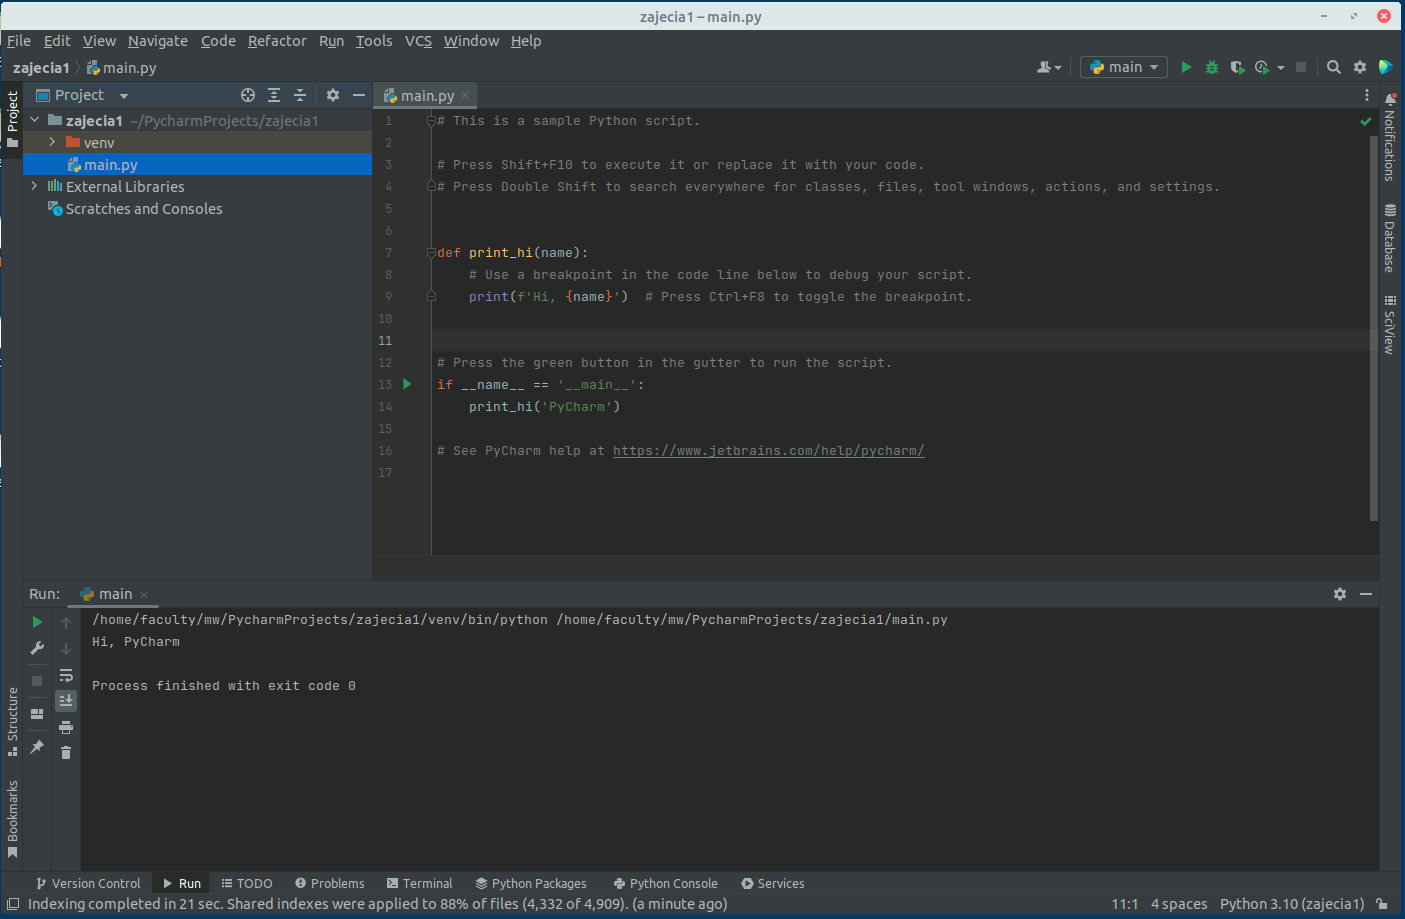

Dokładniej działania edytora i elementy skrótów klawiszowych poznamy na kolejnych zajęciach. Na ten moment istotne będą dwa elementy. Pierwszy to uruchomienie programu za pomocą zielonego trójkąta w górnym prawym rogu ekranu lub po wyborze prawym klawiszem myszy na ekranie z kodem lub pliku i wybór opcji <code>Run 'main'</code>.

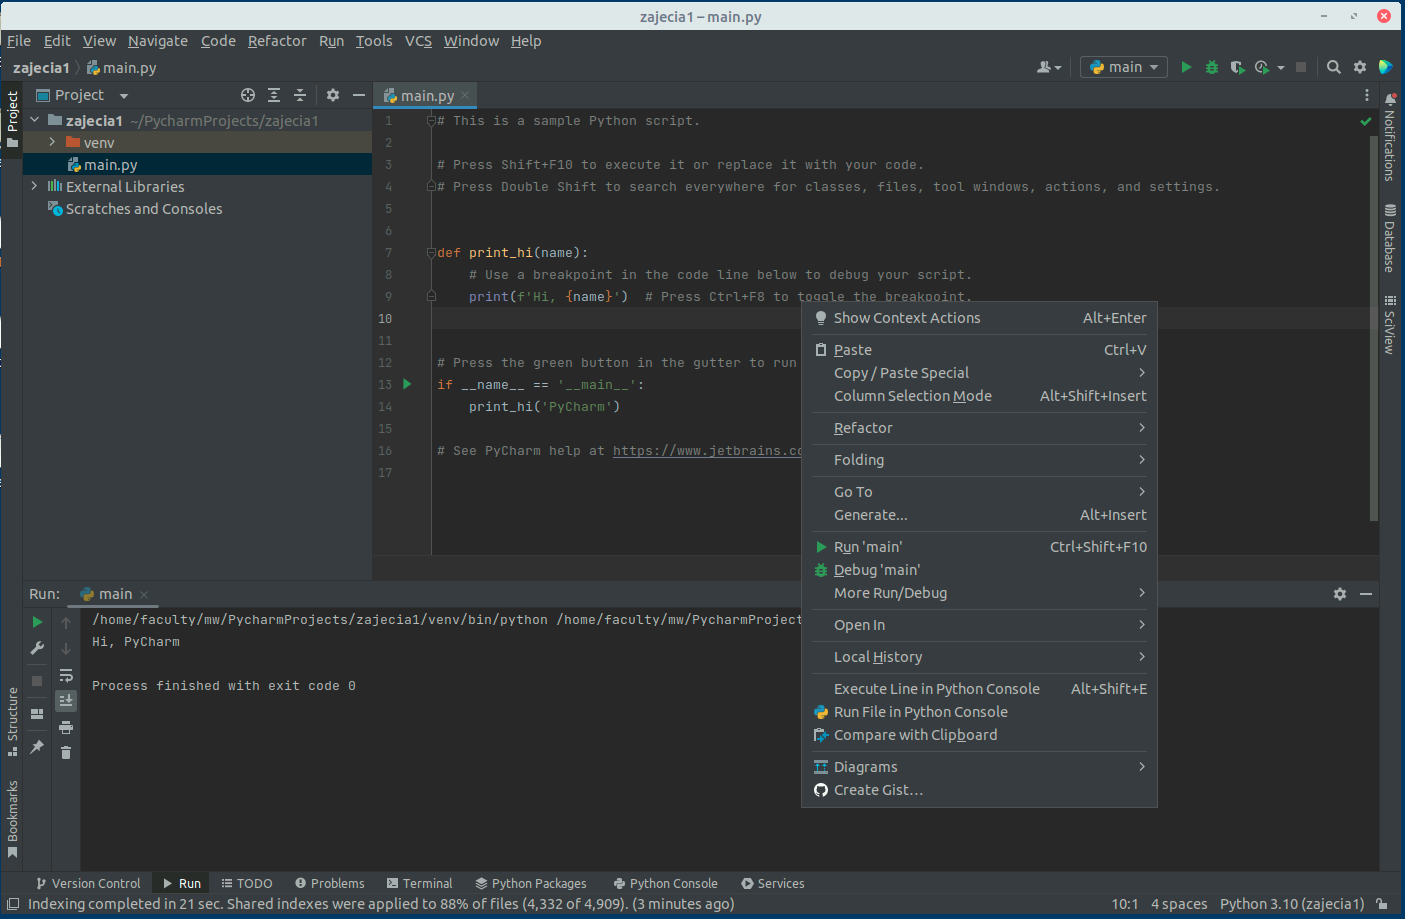

Wiedząc jak uruchamiać programy pozostaje nam poznać sposób dodawania zależności do projektu.

Zależności
-----------

W przypadku gdy wykorzystujemy zewnętrzne moduły przez <code>import</code> może okazać się, że nasze lokalne środowisko nie ma zainstalowanego jakiegoś pakietu lub program nie działa z posiadaną przez nas wersją pakietu, tylko oczekuje konkretnej innej wersji. W takim wypadku z reguły programiści udostępniają plik w którym opisane są zależności projektu.

Standardem dla języka Python jest definiowanie zależności w pliku o nazwie *requirements.txt*.

Dodaj do projektu w **PyCharm** plik *requirements.txt* (prawy klawiszem myszy na folder i **New -> File**). 

W treści pliku umieść.

Multithreading jest biblioteką napisaną przez do kolejkowania i wykonywania zadań wielowątkowo, opiera się ona na module threading który zostanie omówiony w kolejnym rozdziale. Dla nas jest tylko przykładem dla pokazania jak działają zależności i plik requirements w Python. Wybierz w IDE opcję **install requirements**. 

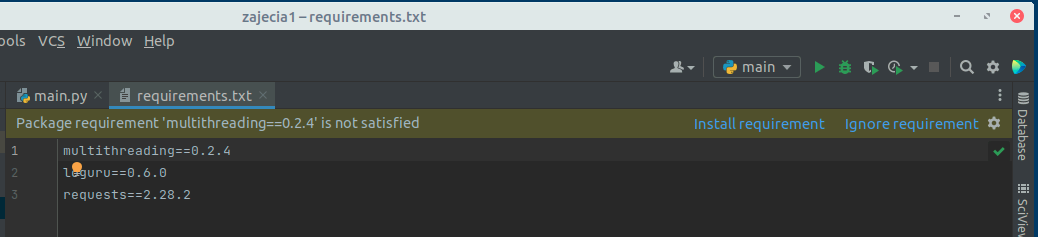

Następnie zamień implementację **main.py** na poniższą i sprawdź czy możesz o uruchomić.

In [1]:
import multithreading

class Demo(multithreading.MultiThread):
    def task(self, task):
        print(task)
        
demo = Demo(threads=3)

# Start threads
demo.start_threads()

# Adding task to queue
demo.add_task(1)
demo.add_task(2)
demo.add_task(3)

# Wait until queue is empty
demo.join()


ModuleNotFoundError: No module named 'multithreading'

Uwaga! W ramach programów uruchamianych przez **Moodle** oraz **Jupyter** nie są dostępne wszystkie zależności i biblioteki a instalacja ich jest możliwa tylko przez administratora systemu (powyżej mamy taki przyklad). W związku z tym w przypadku korzystania z niestandardowych pakietów proszę wykorzystywać **PyCharm**.

Wątki i synchronizacja
========================

W tym rozdziale dowiemy się jak tworzyć wątki w języku Python korzystając ze standardowej biblioteki.

Thread
--------

Standardowa biblioteka Pythona udostępnia moduł *threading*, który zawieraja większość operacji związanych z wielowątkowością. Klasa **Thread** w tym module zapewnia przejrzysty interfejs do pracy z wątkami.

In [9]:
import threading

from time import gmtime, strftime


def thread_function(name):
    
    print("Time %s | Thread %s: starting" % (strftime("%Y-%m-%d %H:%M:%S", gmtime()),name))

    print("Time %s | Thread %s: Name : %s" % (strftime("%Y-%m-%d %H:%M:%S", gmtime()),name,threading.current_thread().name))    
    
    print("Time %s | Thread %s: finishing" % (strftime("%Y-%m-%d %H:%M:%S", gmtime()),name))


print("Time %s | Name : %s" % (strftime("%Y-%m-%d %H:%M:%S", gmtime()),threading.current_thread().name))

print("Time %s | Main Thread : before creating thread" % strftime("%Y-%m-%d %H:%M:%S", gmtime()))

x = threading.Thread(target=thread_function, args=(1,))

print("Time %s | Main Thread : before running thread" % strftime("%Y-%m-%d %H:%M:%S", gmtime()))

x.start()

print("Time %s | Main Thread : wait for the thread to finish" % strftime("%Y-%m-%d %H:%M:%S", gmtime()))

print("Time %s | Main Thread : all done" % strftime("%Y-%m-%d %H:%M:%S", gmtime()))


Time 2023-02-26 18:32:16 | Name : MainThread
Time 2023-02-26 18:32:16 | Main Thread : before creating thread
Time 2023-02-26 18:32:16 | Main Thread : before running thread
Time 2023-02-26 18:32:16 | Thread 1: starting
Time 2023-02-26 18:32:16 | Thread 1: Name : Thread-13
Time 2023-02-26 18:32:16 | Thread 1: finishing
Time 2023-02-26 18:32:16 | Main Thread : wait for the thread to finish
Time 2023-02-26 18:32:16 | Main Thread : all done


Jak widać sam wątek definiujemy w najprostszym scenariuszu poprzez wykonanie 

> <code>threading.Thread(target=thread_function, args=(1,))</code>

Czyli definicję obiektu klasy Thread jako argument podając funkcję, którą wykona nasz wątek oraz parametry tej funkcji. W naszym wypadku przekazujemy tam liczbę, która ma być dla nas naszą *nazwą* aktualnie tworzonego wątku. Aby wątek uruchomić musimy wykonać na tym obiekcie metodę <code>start()</code>.

Powyższy kod zawiera też wywołanie funkcji systemowej <code>gmtime()</code> w celu wypisania czasu wykonania komend.

Kolejna obserwacją którą możemy dokonać jest taka, że w powyższym wykonaniu możemy zaobserwować, że nasz program działa już na dwóch wątkach, pierwszy to tak zwany główny wątek programu, który uruchamiamy startując wykonanie programu. Od niego tworzony jest dopiero drugi wątek. Żeby odczytać nazwę systemową wątku korzystamy z funkcji:

> <code>threading.current_thread().name</code>

Zobaczmy co stanie się gdy zdefiniujemy w kodzie dwa dodatkowe wątki :

In [10]:
import threading

from time import gmtime, strftime


def thread_function(name):
    
    print("Time %s | Thread %s: starting" % (strftime("%Y-%m-%d %H:%M:%S", gmtime()),name))

    print("Time %s | Thread %s: Name : %s" % (strftime("%Y-%m-%d %H:%M:%S", gmtime()),name,threading.current_thread().name))    
    
    print("Time %s | Thread %s: finishing" % (strftime("%Y-%m-%d %H:%M:%S", gmtime()),name))


print("Time %s | Name : %s" % (strftime("%Y-%m-%d %H:%M:%S", gmtime()),threading.current_thread().name))

print("Time %s | Main Thread : before creating thread" % strftime("%Y-%m-%d %H:%M:%S", gmtime()))

x = threading.Thread(target=thread_function, args=(1,))
x2 = threading.Thread(target=thread_function, args=(2,))

print("Time %s | Main Thread : before running thread" % strftime("%Y-%m-%d %H:%M:%S", gmtime()))

x.start()
x2.start()

print("Time %s | Main Thread : wait for the thread to finish" % strftime("%Y-%m-%d %H:%M:%S", gmtime()))

print("Time %s | Main Thread : all done" % strftime("%Y-%m-%d %H:%M:%S", gmtime()))


Time 2023-02-26 18:32:18 | Name : MainThread
Time 2023-02-26 18:32:18 | Main Thread : before creating thread
Time 2023-02-26 18:32:18 | Main Thread : before running thread
Time 2023-02-26 18:32:18 | Thread 1: starting
Time 2023-02-26 18:32:18 | Thread 1: Name : Thread-14
Time 2023-02-26 18:32:18 | Thread 1: finishing
Time 2023-02-26 18:32:18 | Thread 2: starting
Time 2023-02-26 18:32:18 | Thread 2: Name : Thread-15
Time 2023-02-26 18:32:18 | Thread 2: finishing
Time 2023-02-26 18:32:18 | Main Thread : wait for the thread to finish
Time 2023-02-26 18:32:18 | Main Thread : all done


W powyższym przypadku dołożyliśmy dodatkowy wątek i uruchomiliśmy go razem z pierwszym. Bardzo prawdopodobne, że przetwarzanie pierwszego wątku zakończyło się zanim drugi rozpoczął swoje działanie (uruchom komórkę kilka razy - kolejność nie jest zagwarantowana). Nie jest to zapewne oczekiwany efekt. W celu opóźnienia wykonania wątku możemy wykorzystać metodę modułu time o nazwie <code>sleep()</code>.
 
> <code>time.sleep(2)</code>

Powoduje uśpienie wątku na 2 sec. To znaczy zatrzymanie jego wykonywania i oddanie sterowania do innych wątków w systemie. Zobaczmy na efekty zmiany.

In [13]:
import threading
import time

from time import gmtime, strftime


def thread_function(name):
    
    print("Time %s | Thread %s: starting" % (strftime("%Y-%m-%d %H:%M:%S", gmtime()),name))

    print("Time %s | Thread %s: Name : %s" % (strftime("%Y-%m-%d %H:%M:%S", gmtime()),name,threading.current_thread().name))    
    
    time.sleep(2)
    
    print("Time %s | Thread %s: finishing" % (strftime("%Y-%m-%d %H:%M:%S", gmtime()),name))


print("Time %s | Name : %s" % (strftime("%Y-%m-%d %H:%M:%S", gmtime()),threading.current_thread().name))

print("Time %s | Main Thread : before creating thread" % strftime("%Y-%m-%d %H:%M:%S", gmtime()))

x = threading.Thread(target=thread_function, args=(1,))
x2 = threading.Thread(target=thread_function, args=(2,))

print("Time %s | Main Thread : before running thread" % strftime("%Y-%m-%d %H:%M:%S", gmtime()))

x.start()
x2.start()

print("Time %s | Main Thread : wait for the thread to finish" % strftime("%Y-%m-%d %H:%M:%S", gmtime()))

print("Time %s | Main Thread : all done" % strftime("%Y-%m-%d %H:%M:%S", gmtime()))

Time 2023-02-26 18:32:37 | Name : MainThread
Time 2023-02-26 18:32:37 | Main Thread : before creating thread
Time 2023-02-26 18:32:37 | Main Thread : before running thread
Time 2023-02-26 18:32:37 | Thread 1: starting
Time 2023-02-26 18:32:37 | Thread 1: Name : Thread-20
Time 2023-02-26 18:32:37 | Thread 2: starting
Time 2023-02-26 18:32:37 | Thread 2: Name : Thread-21
Time 2023-02-26 18:32:37 | Main Thread : wait for the thread to finish
Time 2023-02-26 18:32:37 | Main Thread : all done
Time 2023-02-26 18:32:39 | Thread 1: finishing
Time 2023-02-26 18:32:39 | Thread 2: finishing


> Zrób to sam!
>> Sprawdź co stanie się gdy zamiast <code>time.sleep(2)</code> zrobisz <code>time.sleep(0)</code>. Czy jak wykonasz tę operację w pętli, powiedzmy 100 razy, to wynik będzie inny ?


Daemon
----------

Co może dziwić w naszym ostatnim przykładzie to to, że nasze wątki kończą się już po tym gdy wątek główny się zakończył. W takim wypadku czy wątek główny nie powinien zamykać całego procesu i tym samym kończyć wykonanie całego programu i potomnych wątków ?

W informatyce **daemon** (demon) to proces działający w tle. W przypadku wątków będących **demonami** zostaną one zamknięte natychmiast po zamknięciu programu. Jednym ze sposobów myślenia o tych definicjach jest rozważenie wątku demona jako wątku działającego w tle bez martwienia się o jego zamknięcie.

Jeśli program uruchamia **wątki**, które **nie są demonami**, program będzie czekał na zakończenie tych wątków przed zakończeniem działania. Jednak wątki, które są demonami, są po prostu zabijane, gdziekolwiek się znajdują, gdy program jest zamykany.

Po zakończeniu programu w Pythonie częścią procesu zamykania jest wyczyszczenie / zamknięcie wątków. Jeśli spojrzysz na źródło implementacji *threading*, zobaczysz, że <code>threading._shutdown()</code> przechodzi przez wszystkie uruchomione wątki i wywołuje <code>.join()</code> na każdym, który nie ma ustawionej flagi **demona**.

Co robi więc funkcja

> <code>join()</code>

Czeka aż wykonanie danego wątku się zakończy, aby przejść dalej.

Najpierw spójrzmy jak będzie wyglądać wykonanie programu w przypadku, gdy nasze wątki będą zdefiniowane jako demony.


In [15]:
import threading
import time

from time import gmtime, strftime


def thread_function(name):
    
    print("Time %s | Thread %s: starting" % (strftime("%Y-%m-%d %H:%M:%S", gmtime()),name))

    print("Time %s | Thread %s: Name : %s" % (strftime("%Y-%m-%d %H:%M:%S", gmtime()),name,threading.current_thread().name))    
    
    time.sleep(2)
    
    print("Time %s | Thread %s: finishing" % (strftime("%Y-%m-%d %H:%M:%S", gmtime()),name))


print("Time %s | Name : %s" % (strftime("%Y-%m-%d %H:%M:%S", gmtime()),threading.current_thread().name))

print("Time %s | Main Thread : before creating thread" % strftime("%Y-%m-%d %H:%M:%S", gmtime()))

x = threading.Thread(target=thread_function, args=(1,), daemon=True)
x2 = threading.Thread(target=thread_function, args=(2,), daemon=True)

print("Time %s | Main Thread : before running thread" % strftime("%Y-%m-%d %H:%M:%S", gmtime()))

x.start()
x2.start()

print("Time %s | Main Thread : wait for the thread to finish" % strftime("%Y-%m-%d %H:%M:%S", gmtime()))

print("Time %s | Main Thread : all done" % strftime("%Y-%m-%d %H:%M:%S", gmtime()))

Time 2023-02-26 18:32:59 | Name : MainThread
Time 2023-02-26 18:32:59 | Main Thread : before creating thread
Time 2023-02-26 18:32:59 | Main Thread : before running thread
Time 2023-02-26 18:32:59 | Thread 1: starting
Time 2023-02-26 18:32:59 | Thread 1: Name : Thread-24
Time 2023-02-26 18:32:59 | Thread 2: starting
Time 2023-02-26 18:32:59 | Thread 2: Name : Thread-25
Time 2023-02-26 18:32:59 | Main Thread : wait for the thread to finish
Time 2023-02-26 18:32:59 | Main Thread : all done
Time 2023-02-26 18:33:01 | Thread 1: finishing
Time 2023-02-26 18:33:01 | Thread 2: finishing


**Uwaga!** W Jupyterze nie zobaczysz tu różnicy - wątki-demony wypiszą komunikat *finishing* tak jak zwykłe wątki. Nie dlatego, że Jupyter blokuje demony, ale dlatego, że **proces** w którym wykonywany jest kod (tzw. *kernel*) nie kończy się razem z wykonaniem komórki. Wątek główny skończył wykonywać komórkę, ale program działa dalej, więc nic nie zabija naszych wątków i spokojnie kończą one pracę. Uruchom powyższy przykład w PyCharm - tam po wypisaniu *all done* proces się zakończy, a komunikaty *finishing* się nie pojawią. W dalszej części (sekcja **Wątek w tle**) zobaczymy też jak ten efekt pokazać w Jupyterze, uruchamiając kod w osobnym procesie.

Teraz zobaczmy co stanie się w przypadku dodania opcji <code>join()</code> przed zakończeniem głównego wątku.

In [14]:
import threading
import time

from time import gmtime, strftime


def thread_function(name):
    
    print("Time %s | Thread %s: starting" % (strftime("%Y-%m-%d %H:%M:%S", gmtime()),name))

    print("Time %s | Thread %s: Name : %s" % (strftime("%Y-%m-%d %H:%M:%S", gmtime()),name,threading.current_thread().name))    
    
    time.sleep(2)
    
    print("Time %s | Thread %s: finishing" % (strftime("%Y-%m-%d %H:%M:%S", gmtime()),name))


print("Time %s | Name : %s" % (strftime("%Y-%m-%d %H:%M:%S", gmtime()),threading.current_thread().name))

print("Time %s | Main Thread : before creating thread" % strftime("%Y-%m-%d %H:%M:%S", gmtime()))

x = threading.Thread(target=thread_function, args=(1,), daemon=True)
x2 = threading.Thread(target=thread_function, args=(2,), daemon=True)

print("Time %s | Main Thread : before running thread" % strftime("%Y-%m-%d %H:%M:%S", gmtime()))

x.start()
x2.start()

print("Time %s | Main Thread : wait for the thread to finish" % strftime("%Y-%m-%d %H:%M:%S", gmtime()))

x.join()
x2.join()

print("Time %s | Main Thread : all done" % strftime("%Y-%m-%d %H:%M:%S", gmtime()))

Time 2023-02-26 18:32:56 | Name : MainThread
Time 2023-02-26 18:32:56 | Main Thread : before creating thread
Time 2023-02-26 18:32:56 | Main Thread : before running thread
Time 2023-02-26 18:32:56 | Thread 1: starting
Time 2023-02-26 18:32:56 | Thread 1: Name : Thread-22
Time 2023-02-26 18:32:56 | Thread 2: starting
Time 2023-02-26 18:32:56 | Thread 2: Name : Thread-23
Time 2023-02-26 18:32:56 | Main Thread : wait for the thread to finish
Time 2023-02-26 18:32:58 | Thread 1: finishing
Time 2023-02-26 18:32:58 | Thread 2: finishing
Time 2023-02-26 18:32:58 | Main Thread : all done


Wątek w tle
-------------

Do czego w praktyce przydają się demony? Typowy przykład to wątek, który działa w nieskończonej pętli "w tle" - np. co pewien czas zapisuje stan programu, sprawdza połączenie z serwerem albo wysyła sygnał "żyję" (ang. *heartbeat*). Taki wątek nigdy sam się nie skończy, więc nie chcemy, żeby program na niego czekał.

Żeby zobaczyć efekt w Jupyterze, uruchomimy nasz program jako **osobny proces** Pythona (moduł <code>subprocess</code>), dokładnie tak jakbyśmy uruchomili go z PyCharm lub z terminala. Program uruchomimy dwa razy: raz z wątkiem będącym demonem, raz ze zwykłym wątkiem. Na wszelki wypadek dajemy procesowi maksymalnie 5 sekund na zakończenie.

In [16]:
import subprocess
import sys

program = """
import threading, time, sys

def heartbeat():
    while True:                      # nieskończona pętla!
        print(".", end="", flush=True)
        time.sleep(0.5)

demon = sys.argv[1] == "daemon"
threading.Thread(target=heartbeat, daemon=demon).start()

time.sleep(2)                        # wątek główny "pracuje" 2 sekundy
print("\\nMain Thread : all done", flush=True)
"""

for tryb in ("daemon", "zwykly"):
    print(f"--- wątek {tryb} ---")
    try:
        wynik = subprocess.run([sys.executable, "-c", program, tryb],
                               capture_output=True, text=True, timeout=5)
        print(wynik.stdout)
        print(f"Proces zakończył się sam (kod wyjścia {wynik.returncode})\n")
    except subprocess.TimeoutExpired as e:
        wyjscie = e.stdout or b""
        print(wyjscie.decode() if isinstance(wyjscie, bytes) else wyjscie)
        print("Proces NIE zakończył się sam - został zabity po 5 sekundach!\n")

--- wątek daemon ---


....
Main Thread : all done

Proces zakończył się sam (kod wyjścia 0)

--- wątek zwykly ---


....
Main Thread : all done
......
Proces NIE zakończył się sam - został zabity po 5 sekundach!



> Zrób to sam!
>> Wyjaśnij, dlaczego w drugim przypadku po komunikacie *all done* pojawiają się kolejne kropki. Co by się stało, gdybyśmy uruchomili ten program w PyCharm bez parametru <code>timeout</code>? (Sprawdź! Program zatrzymasz czerwonym kwadratem w IDE.)
>>
>> Zmień program tak, by wątek główny przed zakończeniem wywoływał <code>join()</code> na wątku-demonie. Czy flaga <code>daemon=True</code> nadal pomaga?

Czy wątki przyspieszają program?
==================================

Skoro możemy uruchomić kilka wątków jednocześnie, to czy program z 4 wątkami wykona się 4 razy szybciej? Sprawdźmy to na dwóch rodzajach zadań:

* zadaniu typu **I/O** (ang. *input/output*) - wątek większość czasu **czeka**: na odpowiedź serwera, odczyt z dysku, dane z sensora. Czekanie zasymulujemy funkcją <code>time.sleep()</code>,
* zadaniu typu **CPU** - wątek cały czas **liczy**, tutaj sumę kwadratów kolejnych liczb.

Zamiast ręcznie tworzyć obiekty <code>Thread</code> skorzystamy z wygodniejszej klasy <code>ThreadPoolExecutor</code> z modułu <code>concurrent.futures</code>. Tworzy ona pulę (ang. *pool*) zadanej liczby wątków i rozdziela między nie zadania. Metoda <code>map</code> działa jak wbudowana funkcja <code>map</code> - wywołuje funkcję dla każdego elementu listy, tylko że w wątkach z puli. Konstrukcja <code>with</code> sprawia, że na końcu bloku czekamy na zakończenie wszystkich wątków (coś jak <code>join()</code>).

In [17]:
import time
from concurrent.futures import ThreadPoolExecutor


def zadanie_io(_):
    time.sleep(1)                              # czekamy, np. na odpowiedź serwera


def zadanie_cpu(_):
    sum(i * i for i in range(3_000_000))       # liczymy


for zadanie in (zadanie_io, zadanie_cpu):
    for liczba_watkow in (1, 4):
        start = time.perf_counter()
        with ThreadPoolExecutor(max_workers=liczba_watkow) as pula:
            list(pula.map(zadanie, range(4)))  # 4 takie same zadania
        print(f"{zadanie.__name__:12} | wątków: {liczba_watkow} | czas: {time.perf_counter() - start:.2f} s")

zadanie_io   | wątków: 1 | czas: 4.00 s


zadanie_io   | wątków: 4 | czas: 1.00 s


zadanie_cpu  | wątków: 1 | czas: 0.45 s


zadanie_cpu  | wątków: 4 | czas: 0.43 s


Zadania typu I/O przyspieszyły mniej więcej 4 razy, ale zadania obliczeniowe... wcale! Dlaczego?

Winny jest **GIL** (ang. *Global Interpreter Lock*). W standardowej implementacji Pythona (CPython) w danej chwili **tylko jeden wątek może wykonywać kod Pythona**, nawet jeśli komputer ma wiele rdzeni. Wątki co chwilę przekazują sobie "pałeczkę" - w efekcie z punktu widzenia programisty działają współbieżnie (na przemian), ale nie równolegle. Wątek, który czeka (<code>sleep</code>, odczyt z sieci, z pliku), oddaje pałeczkę i nie przeszkadza innym - dlatego zadania I/O przyspieszają.

Wniosek: w Pythonie wątki świetnie nadają się do programów, które dużo **czekają** (pobieranie danych z sieci, obsługa wielu klientów, odczyt z sensorów), natomiast do równoległych **obliczeń** wykorzystuje się procesy (moduł <code>multiprocessing</code>) lub biblioteki, które liczą poza interpreterem Pythona (np. NumPy).

**Ciekawostka:** od wersji 3.13 dostępna jest eksperymentalna wersja Pythona bez GIL (tzw. *free-threaded*, uruchamiana jako <code>python3.13t</code>), a od wersji 3.14 jest ona oficjalnie wspierana. W niej powyższe zadania CPU faktycznie przyspieszają. Warto jednak pamiętać, że to, czy w danym miejscu kodu nastąpi przełączenie między wątkami, zależy od wersji interpretera - dlatego programy wielowątkowe muszą być poprawne niezależnie od tego, czy GIL istnieje.

Oś czasu wątków
-----------------

Zobaczmy jak to wygląda na wykresie. Dla każdego wątku zapiszemy moment rozpoczęcia i zakończenia jego zadania, a następnie narysujemy je jako poziome paski (tzw. wykres Gantta). Porównamy wykonanie **sekwencyjne** (zadania jedno po drugim w wątku głównym) z wykonaniem w **4 wątkach**.

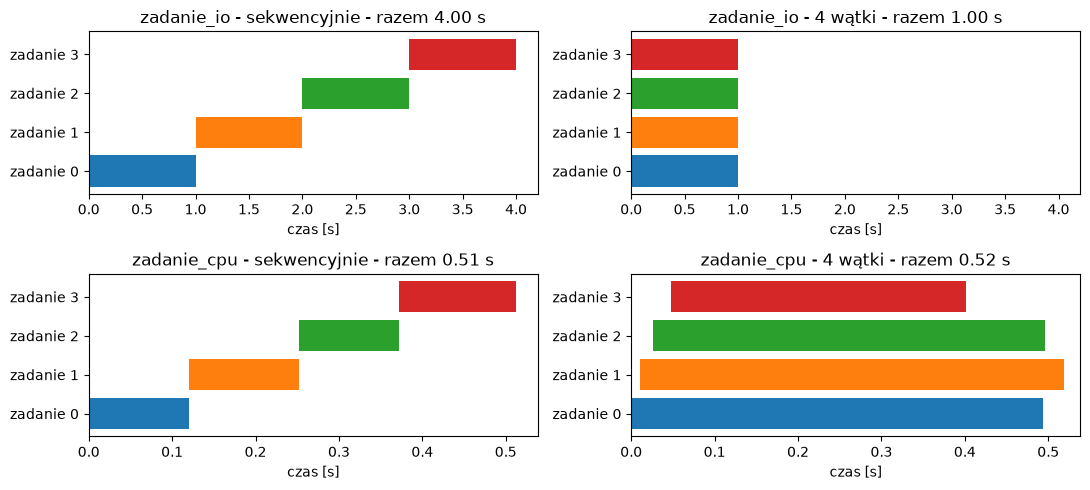

In [18]:
import threading
import time
import matplotlib.pyplot as plt


def zadanie_io():
    time.sleep(1)


def zadanie_cpu():
    sum(i * i for i in range(3_000_000))


def zmierz(zadanie, liczba_zadan=4, w_watkach=True):
    przebiegi = [None] * liczba_zadan          # każdy wątek zapisuje tylko swoje pole
    start0 = time.perf_counter()

    def opakowanie(nr):
        start = time.perf_counter() - start0
        zadanie()
        przebiegi[nr] = (start, time.perf_counter() - start0)

    if w_watkach:
        watki = [threading.Thread(target=opakowanie, args=(nr,)) for nr in range(liczba_zadan)]
        for w in watki:
            w.start()
        for w in watki:
            w.join()
    else:
        for nr in range(liczba_zadan):
            opakowanie(nr)
    return przebiegi


fig, osie = plt.subplots(2, 2, figsize=(11, 5), sharex="row")
for wiersz, zadanie in enumerate((zadanie_io, zadanie_cpu)):
    for kolumna, w_watkach in enumerate((False, True)):
        przebiegi = zmierz(zadanie, w_watkach=w_watkach)
        os_ = osie[wiersz][kolumna]
        for nr, (start, koniec) in enumerate(przebiegi):
            os_.barh(nr, koniec - start, left=start, color=f"C{nr}")
        calosc = max(koniec for _, koniec in przebiegi)
        tryb = "4 wątki" if w_watkach else "sekwencyjnie"
        os_.set_title(f"{zadanie.__name__} - {tryb} - razem {calosc:.2f} s")
        os_.set_yticks(range(len(przebiegi)), [f"zadanie {nr}" for nr in range(len(przebiegi))])
        os_.set_xlabel("czas [s]")
        os_.set_xlim(left=0)
fig.tight_layout()
plt.show()

Na wykresie widać, że przy zadaniach I/O paski wątków nakładają się na siebie i całość trwa tyle co jedno zadanie. Przy zadaniach CPU paski również się nakładają - wątki działają "jednocześnie" - ale każdy z nich jest wielokrotnie dłuższy niż przy wykonaniu sekwencyjnym, bo wątki wykonują się na zmianę i dzielą między siebie jeden "procesor Pythona". Całkowity czas się nie zmienia.

> Zrób to sam!
>> Zwiększ liczbę zadań do 8 (parametr <code>liczba_zadan</code>). Jak zmienia się czas dla zadań I/O, a jak dla CPU?
>>
>> Zmień <code>zadanie_io</code> tak, by wykonywało <code>time.sleep(random.uniform(0.2, 1.5))</code> (pamiętaj o <code>import random</code>). Czym teraz jest całkowity czas wykonania w wątkach?
>>


Błędy jednoczesnego dostępu
-----------------------------

Głównym problemem w przetwarzaniu równoległym jest sytuacja w której wiele wątków wykonuje operacje na tym samym obiekcie. Żeby było to możliwe obiekt ten musi być oczywiście globalny i mutowalny. 

W przypadku, gdy mamy licznik zliczający wykonanie operacji i wątek **A** wykonuje operację  <code>licznik+=1</code> oraz wątek **B** wykonuje tę samą operację, to może dojść do błędu. Wynika on z tego, że operacje odczytu wartości, zwiększenia wartości i zapisania wartości w zmiennej nie są wykonywane **atomowo**. Oznacza to, że wykonanie operacji może zostać przerwane w każdym z tych momentów. 

Załóżmy, że zmienna licznik miała wartość **0**. Wątek **A** odczyta wartość **0** i zostanie przerwany, wtedy w miedzyczasie wątek **B** zwiększy wartość <code>licznik</code> do **1** i wznowi się wątek **A** nie jest on świadomy zmiany wartości, gdyż odczytał już wcześniej **0** i przejdzie do operacji zwiększenia wartości o jeden. W efekcie na koniec przetwarzania wartość <code>licznik</code> będzie równa **1**, a nie **2** jakbyśmy się spodziewali.

Zmienne utworzone poza funkcjami nazywane są **zmiennymi globalnymi**. Zmienne globalne mogą być używane przez wszystkich, zarówno wewnątrz funkcji, jak i na zewnątrz.

In [5]:
licznik = 1

def myfunc():
  print("Licznik wynosi %d" % licznik)

myfunc() 

Licznik wynosi 1


Tutaj widzimy, że uzyskaliśmy dostęp do zmiennej globalnej z wnętrza funkcji.

Jeśli jednak spróbujemy zmodyfikować zmienną globalną z wnętrza funkcji, to otrzymamy błąd:

In [6]:
# global variable
licznik = 1 

def add():

     # increment licznik by 1
    licznik += 1

    print(licznik)

add()

UnboundLocalError: local variable 'licznik' referenced before assignment

Dzieje się tak, ponieważ możemy uzyskać dostęp tylko do zmiennej globalnej, ale nie możemy jej modyfikować z poziomu funkcji.

Rozwiązaniem tego problemu jest użycie słowa kluczowego <code>global</code>.

In [ ]:
# global variable
licznik = 1 

def add():

    # use of global keyword
    global licznik

    # increment c by 2
    licznik += 1 

    print(licznik)

add()

Wyścig w praktyce
-------------------

Spróbujmy wywołać błąd równoczesnego dostępu: 4 wątki zwiększają wspólny licznik po 1 000 000 razy, więc oczekujemy wyniku 4 000 000.

In [19]:
import threading

licznik = 0


def zwiekszaj():
    global licznik
    for _ in range(1_000_000):
        licznik += 1


watki = [threading.Thread(target=zwiekszaj) for _ in range(4)]
for w in watki:
    w.start()
for w in watki:
    w.join()

print(f"Oczekiwano: 4000000, otrzymano: {licznik}")

Oczekiwano: 4000000, otrzymano: 4000000


Najprawdopodobniej wynik jest... poprawny. Czy to znaczy, że problemu nie ma? Nie! Operacja <code>licznik += 1</code> nadal nie jest atomowa, ale w nowszych wersjach Pythona (od 3.10) interpreter przełącza wątki rzadziej i tylko w określonych miejscach kodu, więc przerwanie wątku akurat pomiędzy odczytem a zapisem licznika zdarza się bardzo rzadko. Błąd, który pojawia się raz na milion uruchomień, jest jednak **dużo groźniejszy** od takiego, który pojawia się zawsze - przejdzie wszystkie testy, a ujawni się dopiero u klienta (lub na innej wersji Pythona, np. bez GIL).

Żeby zobaczyć problem na własne oczy, rozbijmy operację <code>licznik += 1</code> na trzy kroki opisane wcześniej: odczyt, zwiększenie i zapis. Pomiędzy odczytem a zapisem wywołamy <code>time.sleep(0)</code>, czyli poprosimy system, by w tym miejscu oddał sterowanie innemu wątkowi - dokładnie tak jak w scenariuszu z wątkami **A** i **B** opisanym na początku rozdziału.

In [20]:
import threading
import time

licznik = 0


def zwiekszaj():
    global licznik
    for _ in range(1000):
        odczyt = licznik         # 1. odczyt wartości
        time.sleep(0)            #    ... tu inny wątek może nas wyprzedzić
        licznik = odczyt + 1     # 2. zwiększenie i 3. zapis


watki = [threading.Thread(target=zwiekszaj) for _ in range(4)]
for w in watki:
    w.start()
for w in watki:
    w.join()

print(f"Oczekiwano: 4000, otrzymano: {licznik}")

Oczekiwano: 4000, otrzymano: 1000


Tym razem wynik jest bliski 1000 zamiast 4000 - prawie wszystkie zwiększenia licznika zostały "zgubione", bo wątki nadpisywały sobie nawzajem wyniki. Taką sytuację, w której wynik programu zależy od tego, w jakiej kolejności wykonają się wątki, nazywamy **wyścigiem** (ang. *race condition*). Jak się przed nim bronić, dowiemy się na kolejnych zajęciach.

> Zrób to sam!
>> Uruchom komórkę kilka razy. Czy wynik jest za każdym razem taki sam?
>>
>> Zmień liczbę wątków na 1. Czy błąd nadal występuje? A gdy usuniesz linię <code>time.sleep(0)</code>?

Wykonaj zadanie na **moodle** by zaobserwować w praktyce błąd równoczesnego dostępu do zmiennej.

**Uwaga!** to czy wywołanie błędu się powiedzie zależy od stanu systemu w danej chwili i wersji Pythona. Jeśli mimo kilku uruchomień błąd się nie pojawia, wykorzystaj trik z <code>time.sleep(0)</code> pokazany powyżej, by zwiększyć szansę na przełączenie wątku w "złym" momencie.

Print
----------

Czy funkcja <code>print</code> wywoływana z wielu wątków jednocześnie zawsze wypisze nasze komunikaty w całości? Niestety nie. Wywołanie <code>print("Wątek", n, "krok", i)</code> nie jest jedną operacją - <code>print</code> zapisuje na wyjście po kolei każdy argument, separator (spację) i na końcu znak nowej linii. Pomiędzy tymi zapisami inny wątek może wypisać swój tekst.

Sprawdźmy to - 4 wątki wypisują po 1000 linii, a my policzymy ile z nich zostało "zepsutych". Jupyter przechwytuje wyjście programu na swój sposób, dlatego - podobnie jak w sekcji **Wątek w tle** - uruchomimy program jako osobny proces, tak jak zrobiłby to PyCharm.

In [21]:
import re
import subprocess
import sys

program = """
import threading, sys

jeden_zapis = sys.argv[1] == "tak"

def wypisuj(n):
    for i in range(1000):
        if jeden_zapis:
            print(f"Wątek {n} krok {i}\\n", end="")   # cała linia jednym zapisem
        else:
            print("Wątek", n, "krok", i)

watki = [threading.Thread(target=wypisuj, args=(n,)) for n in range(4)]
for w in watki:
    w.start()
for w in watki:
    w.join()
"""


def uruchom(jeden_zapis):
    wyjscie = subprocess.run([sys.executable, "-c", program, "tak" if jeden_zapis else "nie"],
                             capture_output=True, text=True).stdout
    linie = wyjscie.splitlines()
    zepsute = [l for l in linie if not re.fullmatch(r"Wątek \d krok \d+", l)]
    print(f"Wszystkich linii: {len(linie)}, w tym zepsutych: {len(zepsute)}")
    for linia in zepsute[:5]:
        print(f"   {linia!r}")


uruchom(jeden_zapis=False)

Wszystkich linii: 4000, w tym zepsutych: 3795
   'Wątek 0WątekWątek krok  2Wątek4   '
   '13Wątek krok  krok0'
   '  Wątek0 '
   'Wątekkrok3  0krok   1krok0  '
   'krok15'


Liczba zepsutych linii zależy od systemu i od uruchomienia, ale zwykle jest ich bardzo dużo - fragmenty komunikatów różnych wątków są ze sobą przemieszane, np. <code>'Wątek 1 krok 0Wątek'</code>.

Dodatkowo nie ma gwarancji, że komunikaty pojawią się na ekranie w kolejności, w jakiej zostały wykonane operacje w różnych wątkach (czyli np. w przypadku wyjątku możemy otrzymać informację o błędzie przed otrzymaniem wszystkich oczekiwanych komunikatów na ekranie).

Jak sobie z tym radzić bez wprowadzania mechanizmów synchronizacji? Najprościej zadbać, by każdy komunikat był wypisywany **jednym zapisem**: najpierw zbudować cały tekst razem ze znakiem nowej linii, a potem przekazać go do <code>print</code> jako jeden argument z <code>end=""</code> (gałąź <code>jeden_zapis</code> w programie powyżej). Komunikaty różnych wątków nadal mogą pojawiać się w dowolnej kolejności, ale każda linia będzie cała.

In [22]:
uruchom(jeden_zapis=True)

Wszystkich linii: 4000, w tym zepsutych: 0


W większych programach zamiast <code>print</code> warto korzystać z modułu <code>logging</code> (lub biblioteki <code>loguru</code> z naszego pliku *requirements.txt*). Biblioteki do logowania są przygotowane do pracy z wieloma wątkami, a dodatkowo potrafią automatycznie dopisać do komunikatu czas i nazwę wątku - nie musimy więc za każdym razem ręcznie wywoływać <code>strftime</code> i <code>threading.current_thread().name</code> jak w przykładach powyżej.

In [23]:
import logging
import threading
import time

logging.basicConfig(format="%(asctime)s | %(threadName)-10s | %(message)s",
                    level=logging.INFO, force=True)


def thread_function(name):
    logging.info("Thread %s: starting", name)
    time.sleep(2)
    logging.info("Thread %s: finishing", name)


logging.info("Main Thread : before creating thread")
watki = [threading.Thread(target=thread_function, args=(n,), name=f"Watek-{n}") for n in (1, 2)]
for w in watki:
    w.start()
for w in watki:
    w.join()
logging.info("Main Thread : all done")

2026-10-03 16:48:57,905 | MainThread | Main Thread : before creating thread


2026-10-03 16:48:57,906 | Watek-1    | Thread 1: starting


2026-10-03 16:48:57,907 | Watek-2    | Thread 2: starting


2026-10-03 16:48:59,907 | Watek-1    | Thread 1: finishing


2026-10-03 16:48:59,909 | Watek-2    | Thread 2: finishing


2026-10-03 16:48:59,910 | MainThread | Main Thread : all done
